# =============================
# 1. Importaciones
# =============================

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (make_scorer, classification_report, confusion_matrix,
                             recall_score, accuracy_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import calibration_curve

# Para definir distribuciones en RandomizedSearchCV
from scipy.stats import randint

# =============================
# 2. Función de Costo
# =============================

In [2]:

def cost_metric(y_true, y_pred, cost_fn=10, cost_fp=1):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    FN = np.sum((y_true == 1) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    cost = cost_fn * FN + cost_fp * FP
    return -cost  # Retornamos negativo para que mayor sea mejor

cost_scorer = make_scorer(cost_metric, greater_is_better=True)

# =============================
# 3. Cargar y Preprocesar el Dataset
# =============================

In [3]:

df = pd.read_csv('lung_cancer_prediction.csv')

columns_to_drop = [
    'Country',
    'Language_Barrier',
    'Insurance_Coverage',
    'Clinical_Trial_Access',
    'Treatment_Access',
    'Tobacco_Marketing_Exposure'
]
df = df.drop(columns=columns_to_drop)

if df['Final_Prediction'].dtype == 'object':
    df['Final_Prediction'] = df['Final_Prediction'].astype('category').cat.codes

X = df.drop(columns=['Final_Prediction'])
y = df['Final_Prediction']

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['number']).columns.tolist()

print("Variables categóricas a codificar:", categorical_features)
print("Variables numéricas:", numerical_features)

Variables categóricas a codificar: ['Gender', 'Smoking_Status', 'Second_Hand_Smoke', 'Air_Pollution_Exposure', 'Occupation_Exposure', 'Rural_or_Urban', 'Socioeconomic_Status', 'Healthcare_Access', 'Screening_Availability', 'Stage_at_Diagnosis', 'Cancer_Type', 'Mutation_Type', 'Delay_in_Diagnosis', 'Family_History', 'Indoor_Smoke_Exposure']
Variables numéricas: ['Age', 'Mortality_Risk', '5_Year_Survival_Probability']


# =============================
# Exploratory Data Analysis (EDA)
# =============================


=== Vistas Resumidas del Dataset ===
Head:
   Age  Gender Smoking_Status Second_Hand_Smoke Air_Pollution_Exposure  \
0   82    Male  Former Smoker               Yes                 Medium   
1   66  Female  Former Smoker                No                   High   
2   87    Male  Former Smoker                No                 Medium   
3   51  Female  Former Smoker                No                    Low   
4   43    Male  Former Smoker                No                   High   

  Occupation_Exposure Rural_or_Urban Socioeconomic_Status Healthcare_Access  \
0                  No          Urban                 High           Limited   
1                  No          Rural               Middle              Good   
2                  No          Urban                  Low              Poor   
3                 Yes          Rural                 High              Good   
4                  No          Urban               Middle              Good   

  Screening_Availability Stage_at_Di

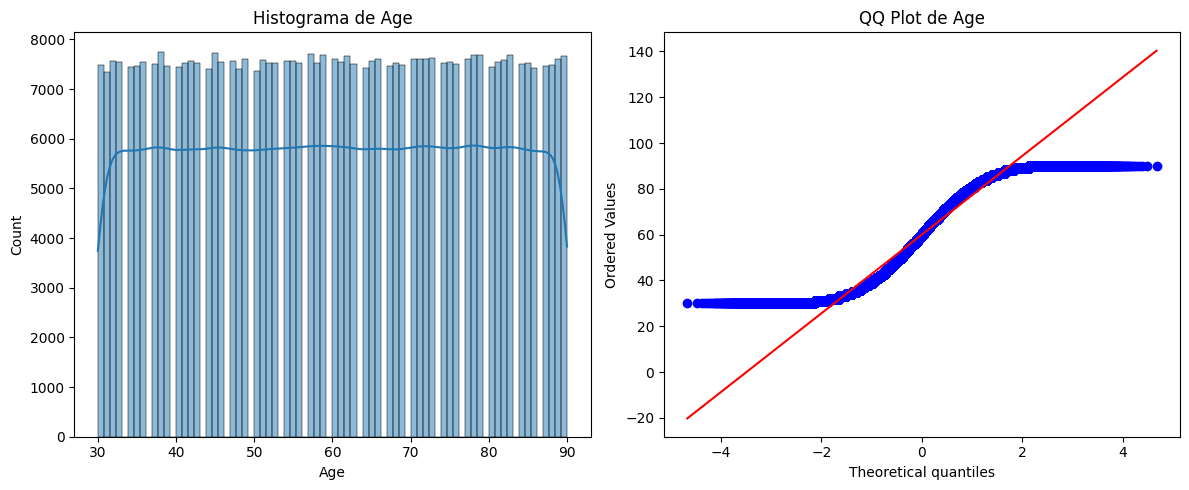

D’Agostino’s K² test p-value: 0.0000
Shapiro-Wilk test p-value: 0.0000


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 460292.
  res = hypotest_fun_out(*samples, **kwds)


Anderson-Darling test statistic: 5163.2765
   Significance Level 15.0%: Critical Value 0.5760
   Significance Level 10.0%: Critical Value 0.6560
   Significance Level 5.0%: Critical Value 0.7870
   Significance Level 2.5%: Critical Value 0.9180
   Significance Level 1.0%: Critical Value 1.0920

--- Normality Tests para Mortality_Risk ---


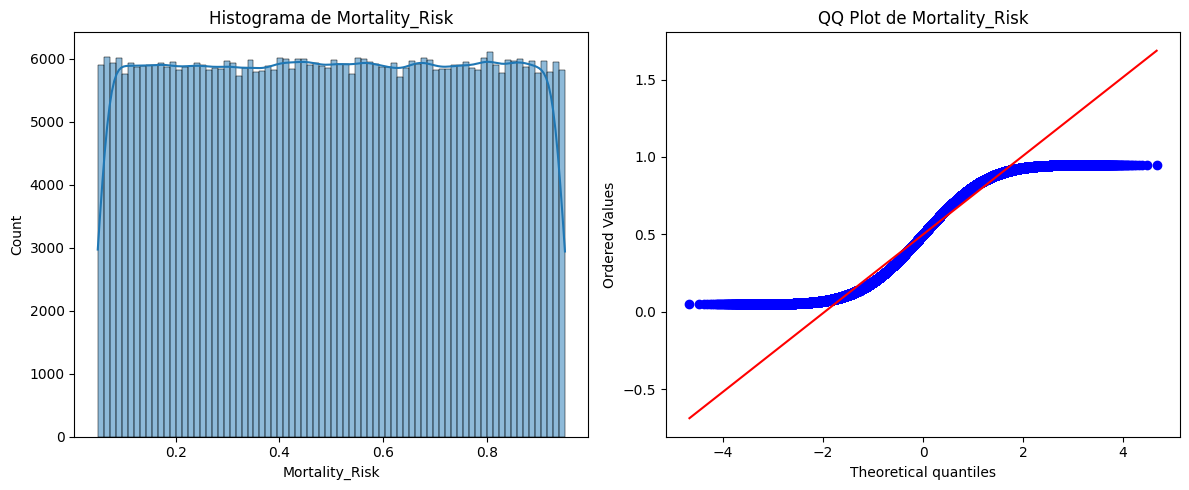

D’Agostino’s K² test p-value: 0.0000
Shapiro-Wilk test p-value: 0.0000
Anderson-Darling test statistic: 5111.5922
   Significance Level 15.0%: Critical Value 0.5760
   Significance Level 10.0%: Critical Value 0.6560
   Significance Level 5.0%: Critical Value 0.7870
   Significance Level 2.5%: Critical Value 0.9180
   Significance Level 1.0%: Critical Value 1.0920

--- Normality Tests para 5_Year_Survival_Probability ---


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 460292.
  res = hypotest_fun_out(*samples, **kwds)


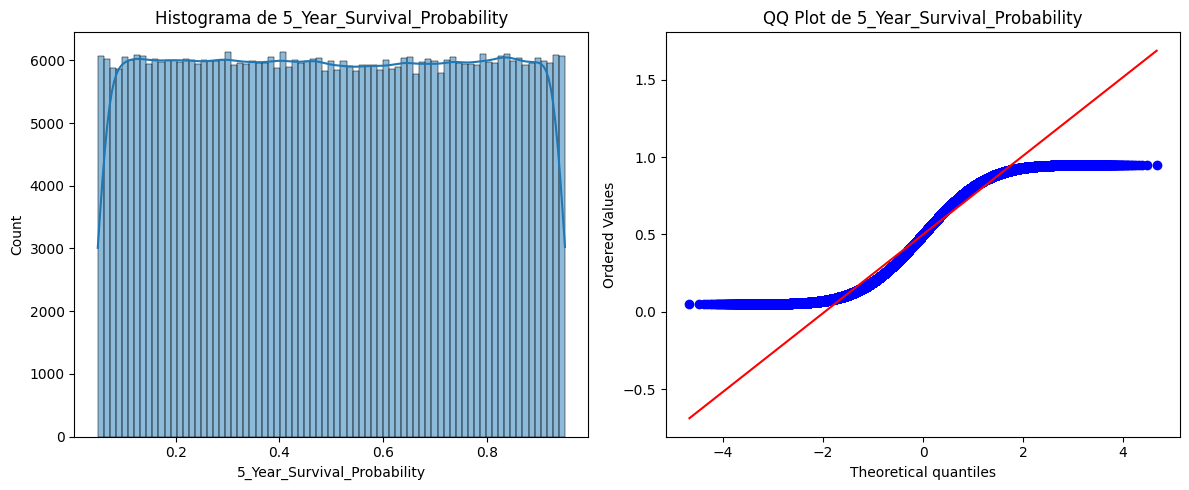

D’Agostino’s K² test p-value: 0.0000
Shapiro-Wilk test p-value: 0.0000
Anderson-Darling test statistic: 5198.0512
   Significance Level 15.0%: Critical Value 0.5760
   Significance Level 10.0%: Critical Value 0.6560
   Significance Level 5.0%: Critical Value 0.7870
   Significance Level 2.5%: Critical Value 0.9180
   Significance Level 1.0%: Critical Value 1.0920


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 460292.
  res = hypotest_fun_out(*samples, **kwds)


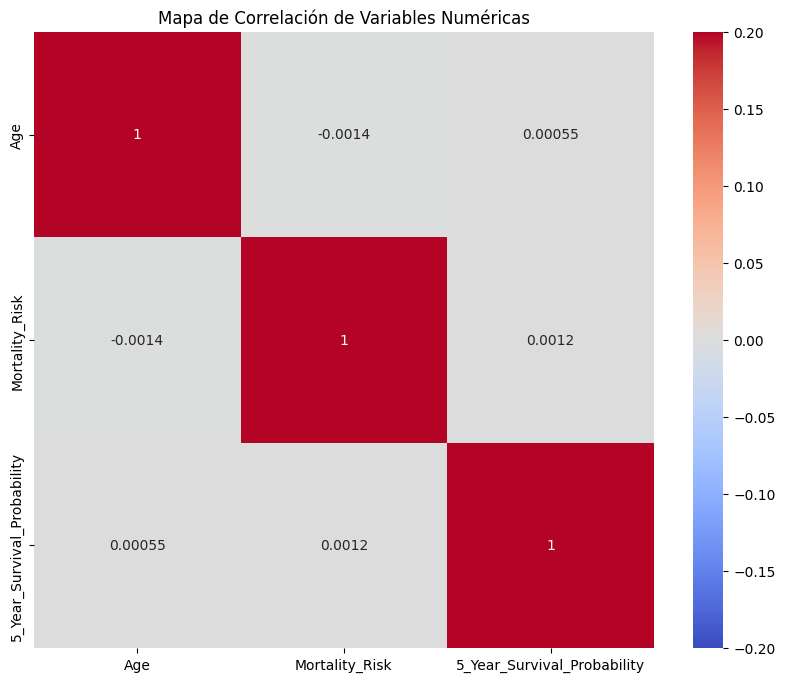

<Figure size 800x500 with 0 Axes>

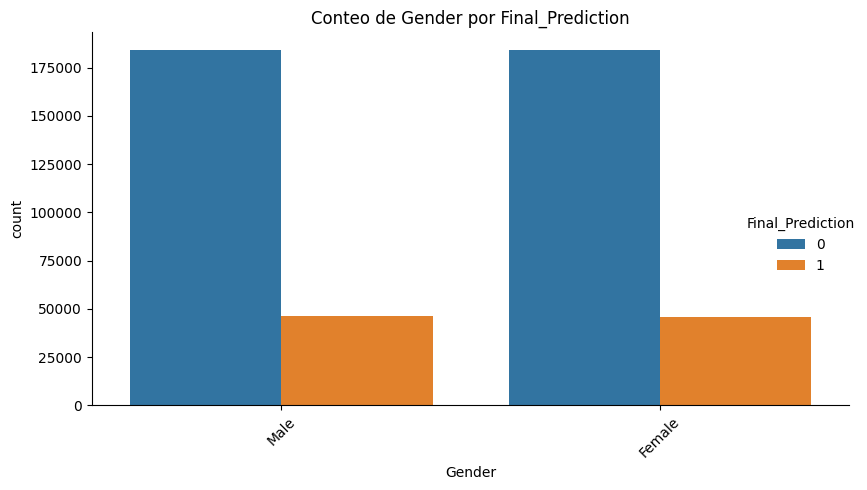

<Figure size 800x500 with 0 Axes>

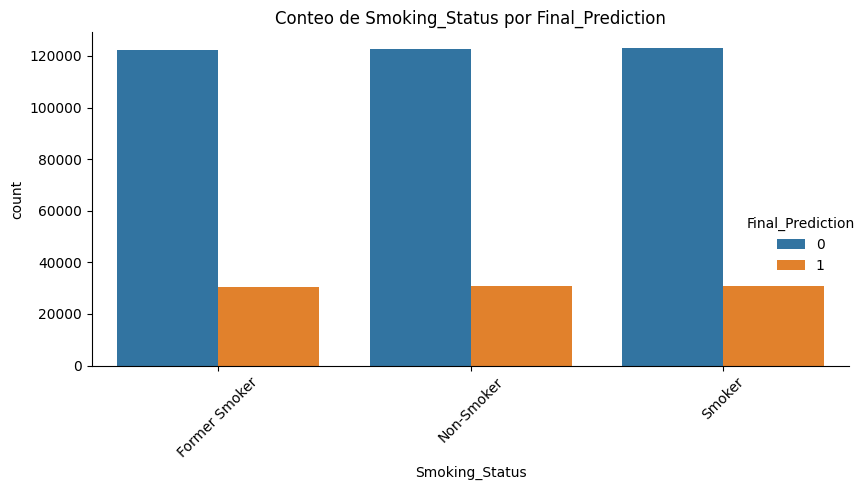

<Figure size 800x500 with 0 Axes>

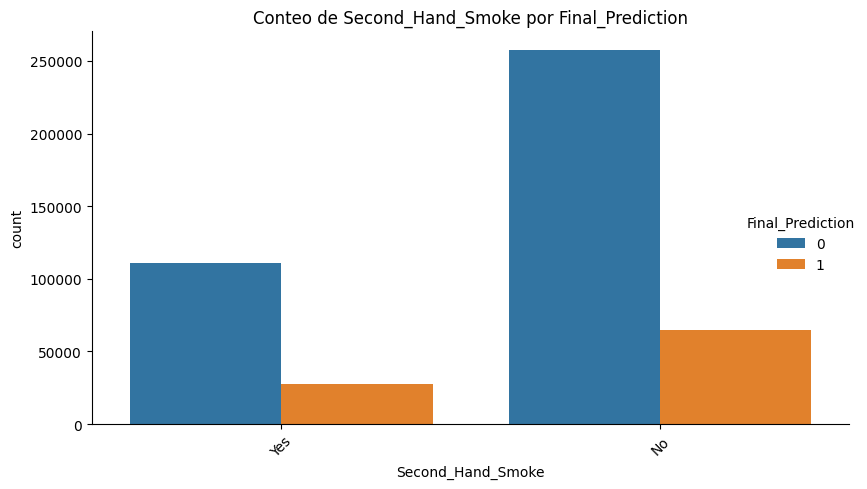

<Figure size 800x500 with 0 Axes>

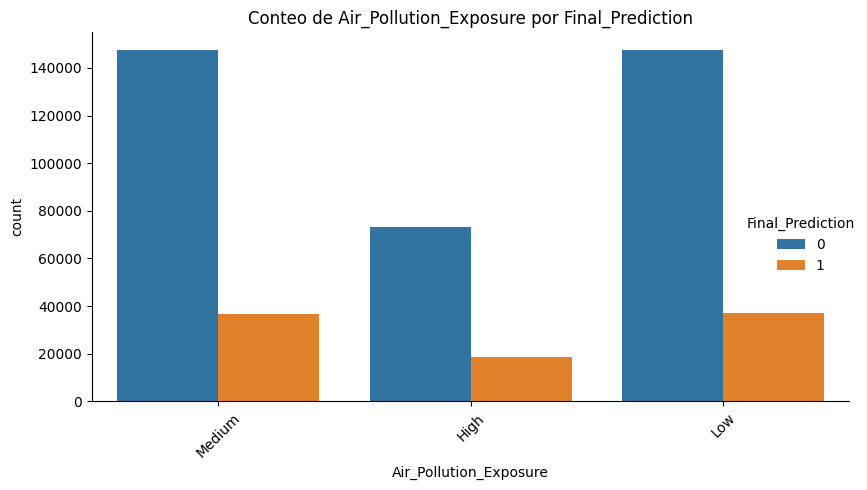

<Figure size 800x500 with 0 Axes>

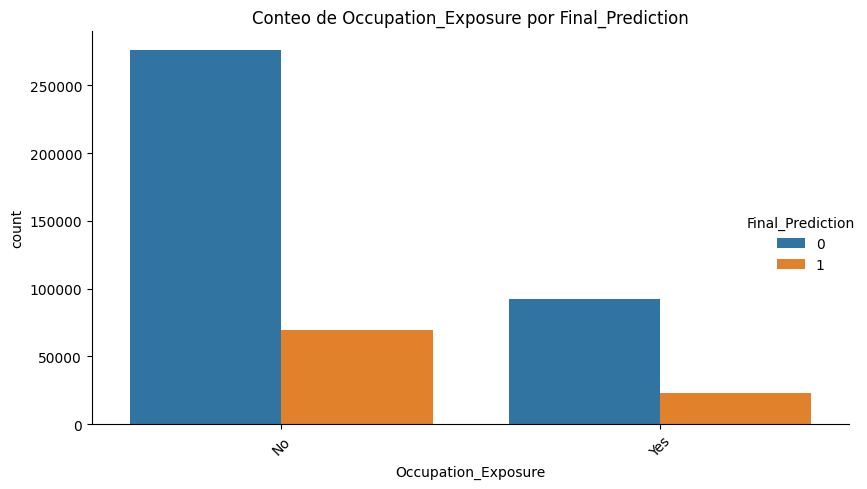

<Figure size 800x500 with 0 Axes>

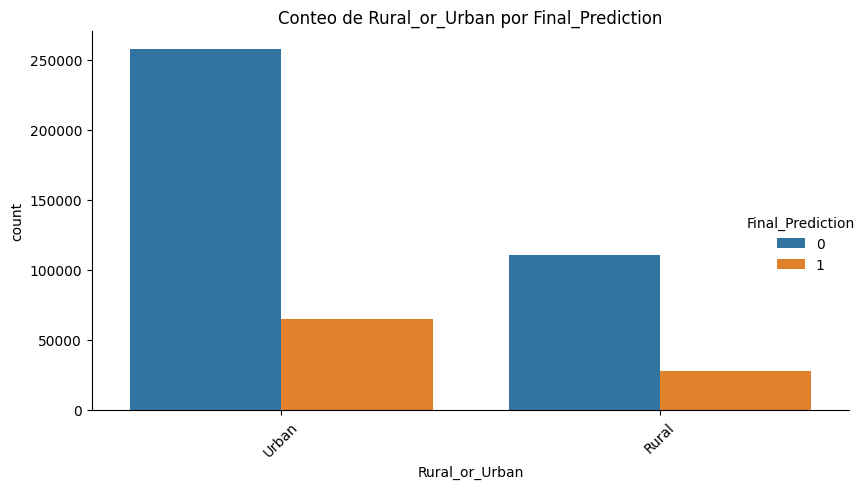

<Figure size 800x500 with 0 Axes>

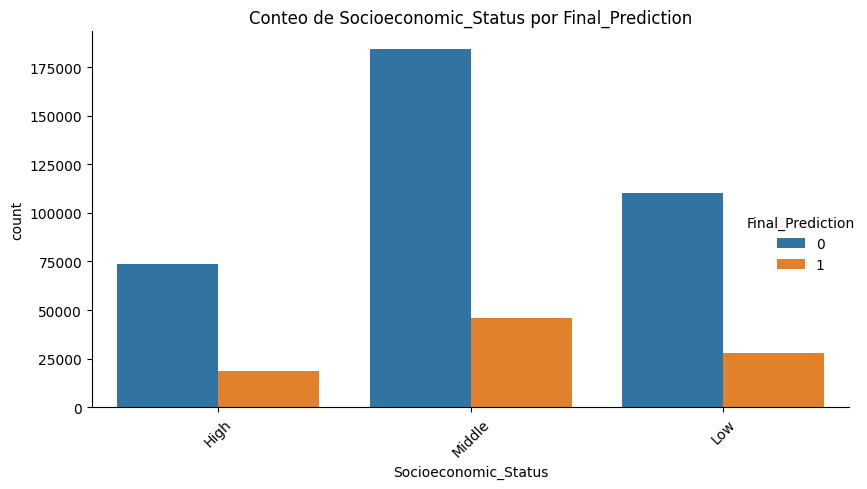

<Figure size 800x500 with 0 Axes>

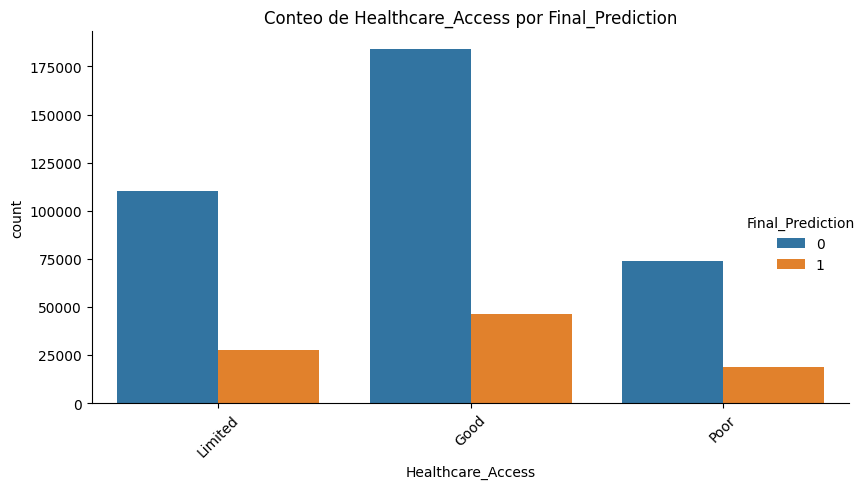

<Figure size 800x500 with 0 Axes>

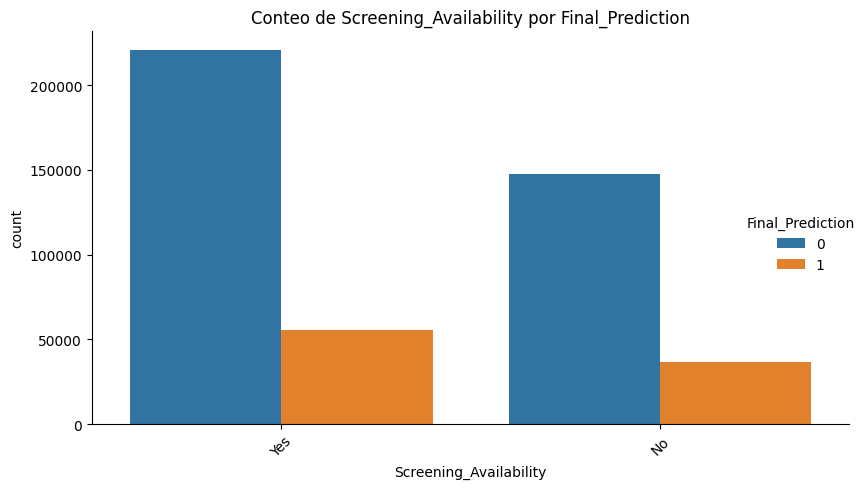

<Figure size 800x500 with 0 Axes>

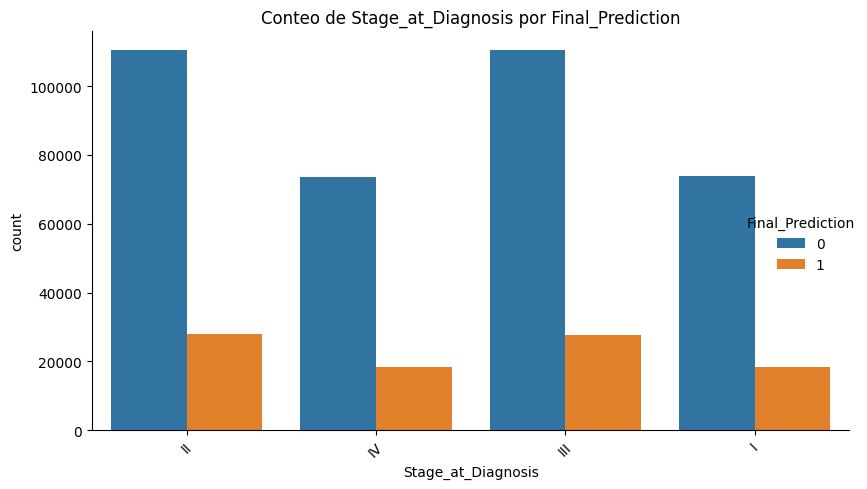

<Figure size 800x500 with 0 Axes>

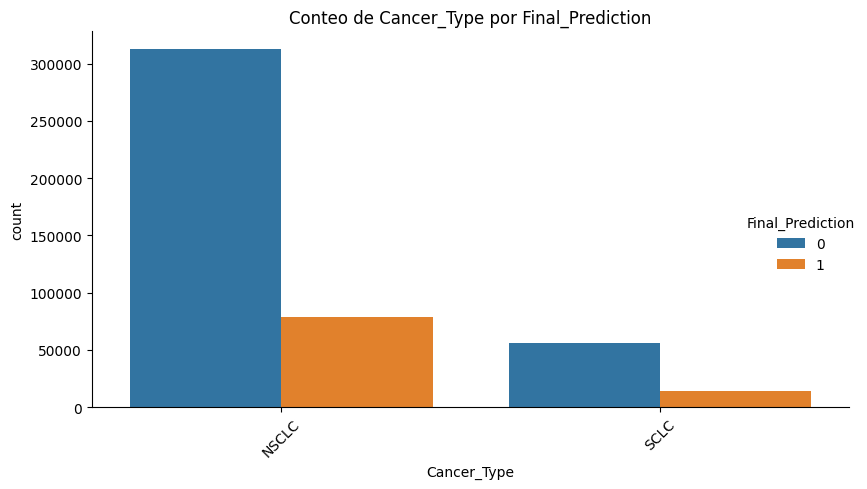

<Figure size 800x500 with 0 Axes>

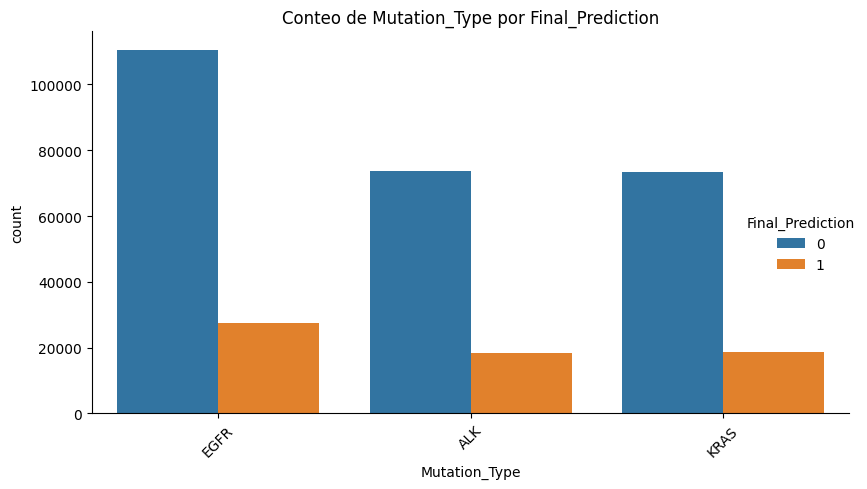

<Figure size 800x500 with 0 Axes>

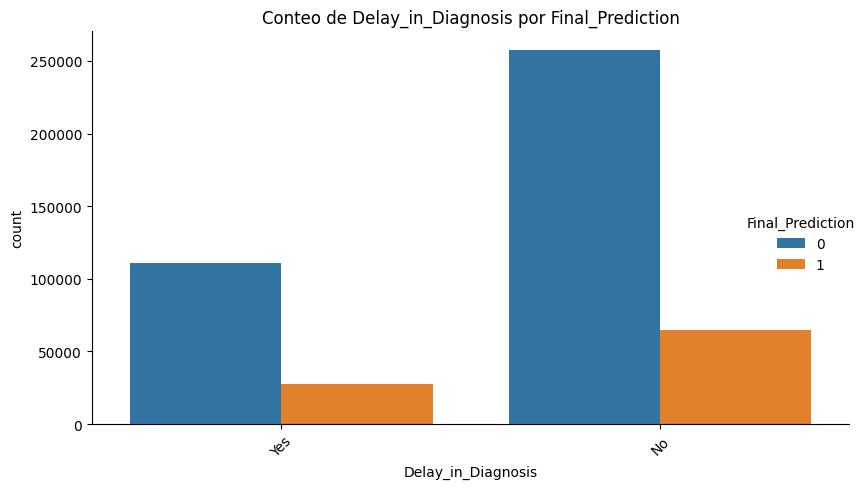

<Figure size 800x500 with 0 Axes>

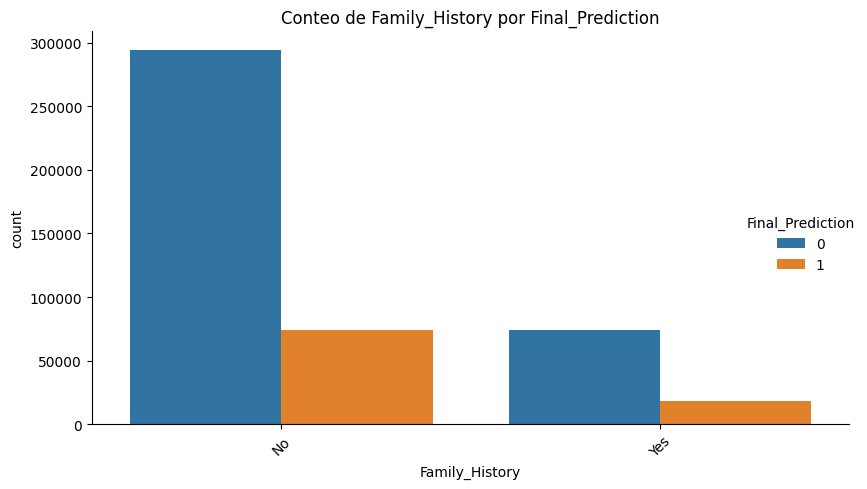

<Figure size 800x500 with 0 Axes>

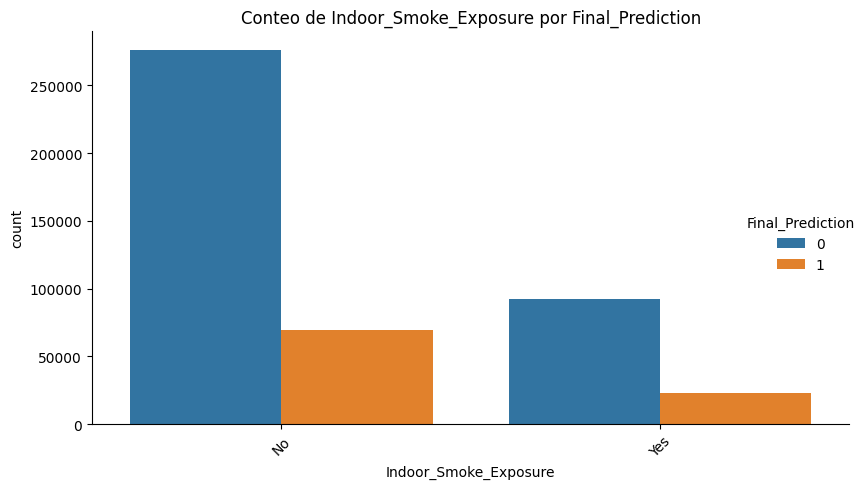

In [4]:

print("\n=== Vistas Resumidas del Dataset ===")
print("Head:")
print(df.head())
print("\nTail:")
print(df.tail())
print("\nDescribe:")
print(df.describe())
print("\nShape:", df.shape)
print("\nMissing values por columna:")
print(df.isna().sum())

# Pruebas de normalidad para cada variable numérica
for col in numerical_features:
    print(f"\n--- Normality Tests para {col} ---")
    data = df[col].dropna()
    
    # Histograma y QQ plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(data, kde=True)
    plt.title(f'Histograma de {col}')
    
    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'QQ Plot de {col}')
    
    plt.tight_layout()
    plt.show()
    
    # D’Agostino’s K^2 Test
    k2, p_dagostino = stats.normaltest(data)
    print(f"D’Agostino’s K² test p-value: {p_dagostino:.4f}")
    
    # Shapiro-Wilk Test
    stat_shapiro, p_shapiro = stats.shapiro(data)
    print(f"Shapiro-Wilk test p-value: {p_shapiro:.4f}")
    
    # Anderson-Darling Test
    result_anderson = stats.anderson(data, dist='norm')
    print("Anderson-Darling test statistic: %.4f" % result_anderson.statistic)
    for i, (sl, cv) in enumerate(zip(result_anderson.significance_level, result_anderson.critical_values)):
        print(f"   Significance Level {sl}%: Critical Value {cv:.4f}")

# Correlation plot de variables numéricas
plt.figure(figsize=(10, 8))
corr = df[numerical_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-0.2, vmax=0.2)
plt.title("Mapa de Correlación de Variables Numéricas")
plt.show()

# Factor plot (catplot) para variables categóricas
for col in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.catplot(x=col, hue="Final_Prediction", kind="count", data=df, height=5, aspect=1.5)
    plt.title(f'Conteo de {col} por Final_Prediction')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =============================
# Visualización exploratoria de variables según Final_Prediction
# =============================

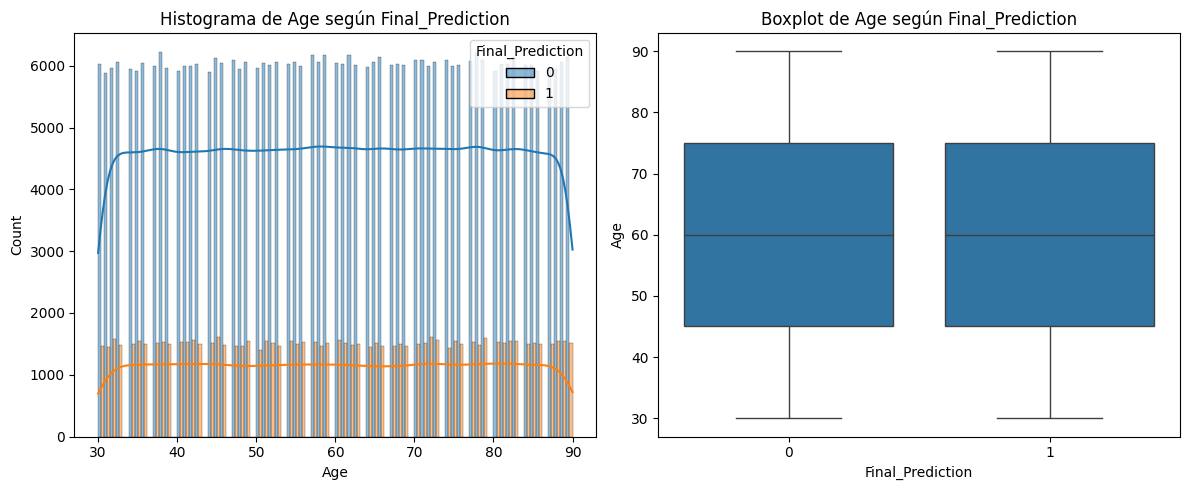

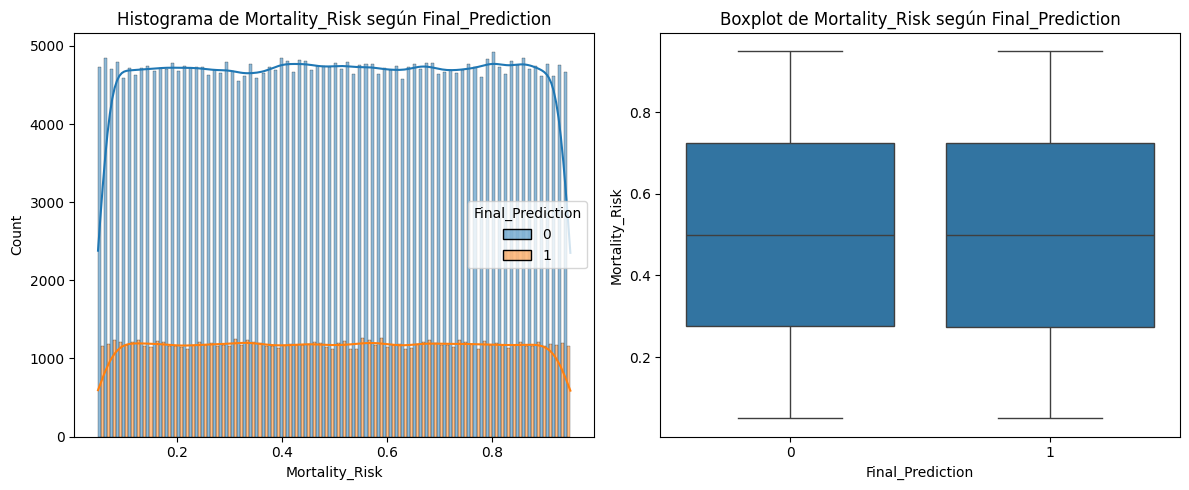

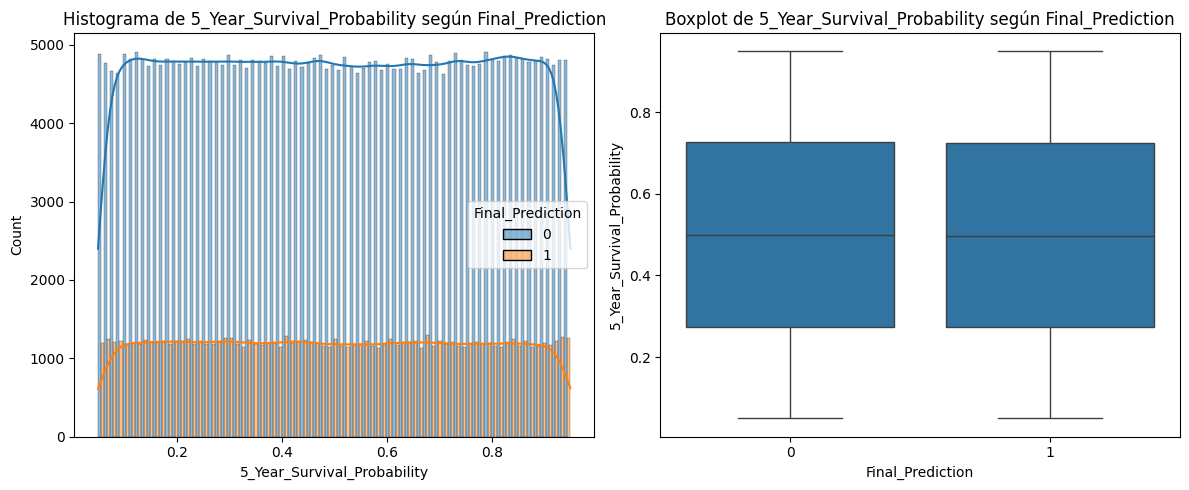

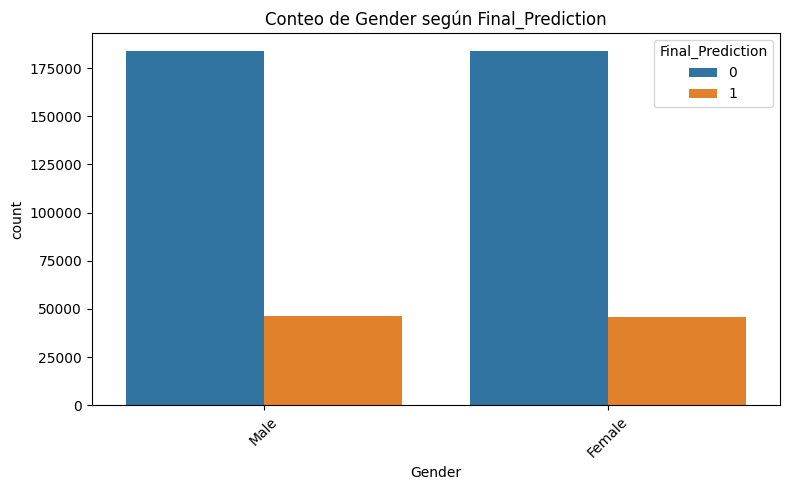

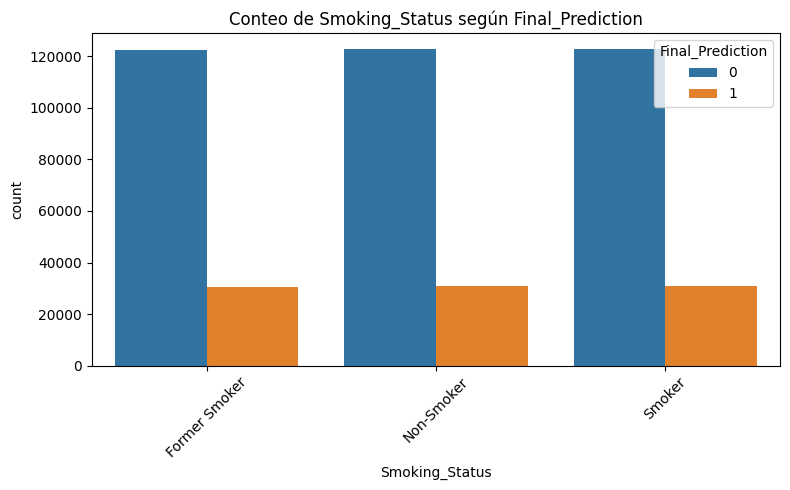

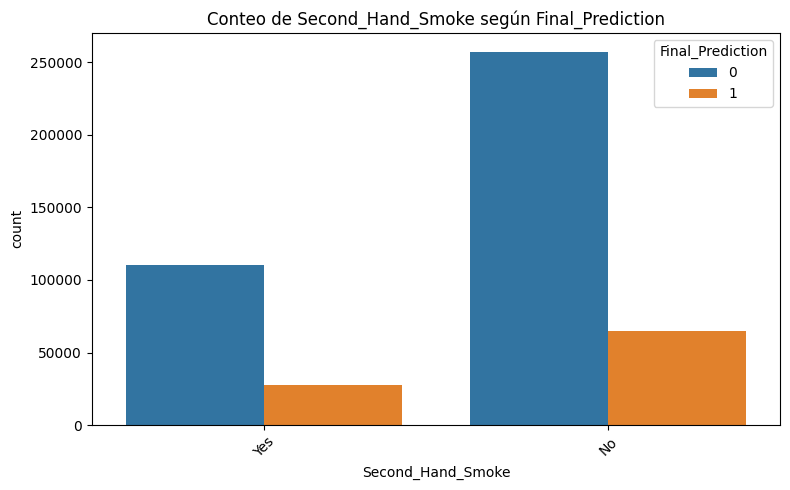

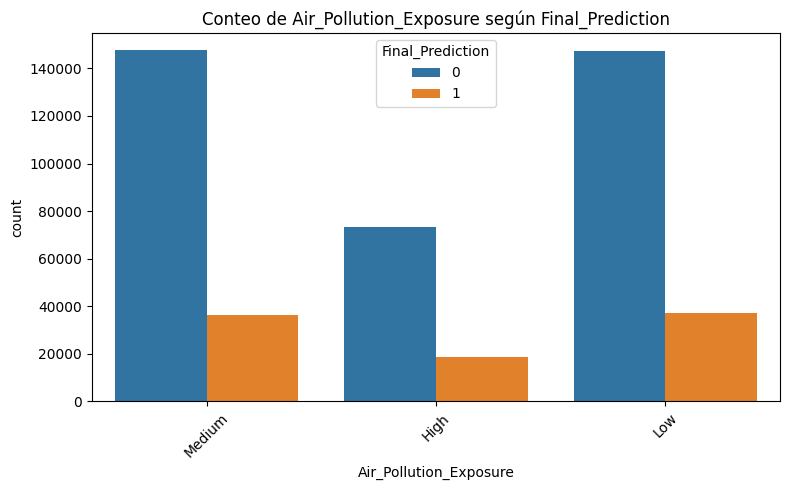

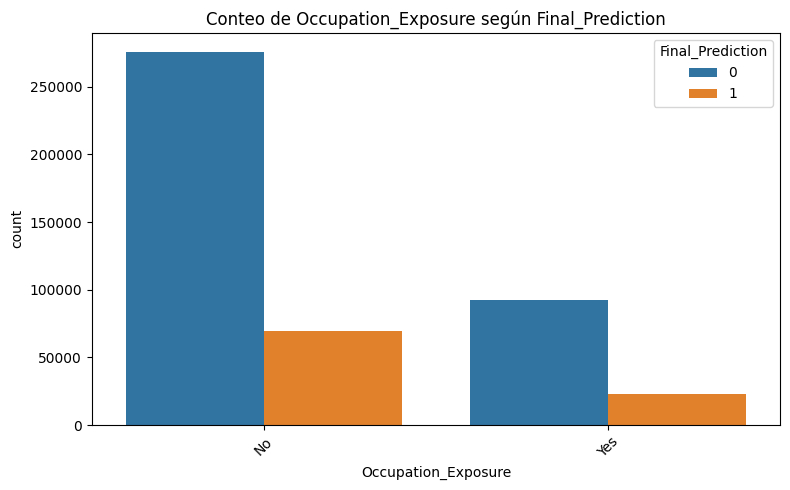

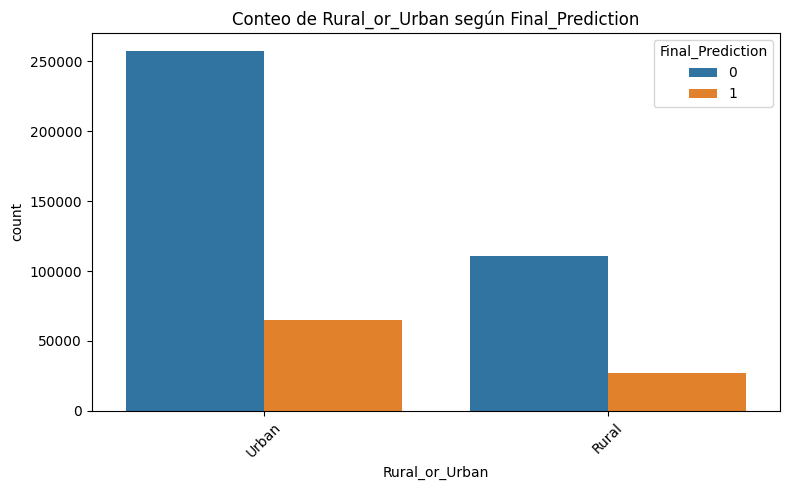

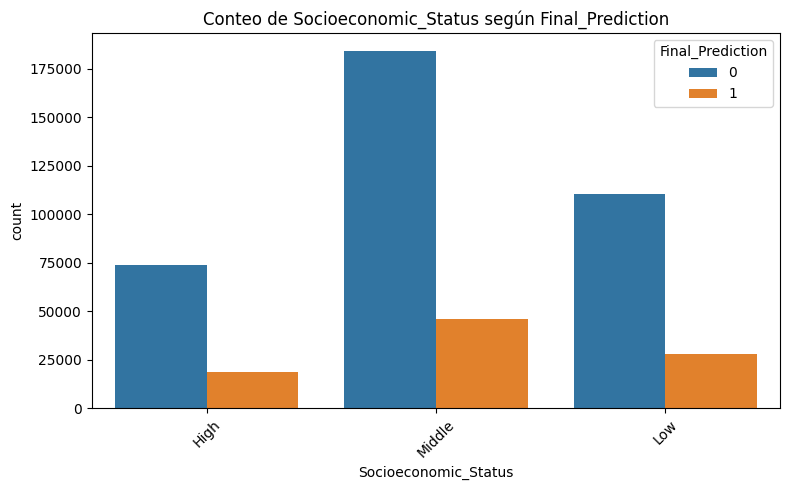

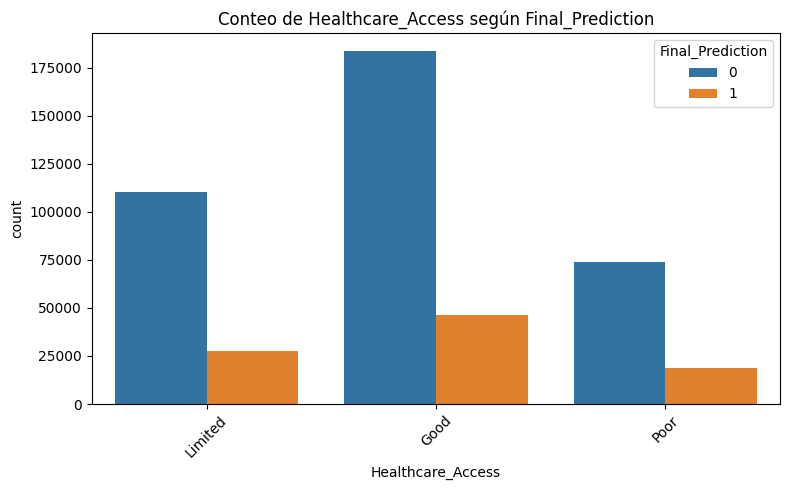

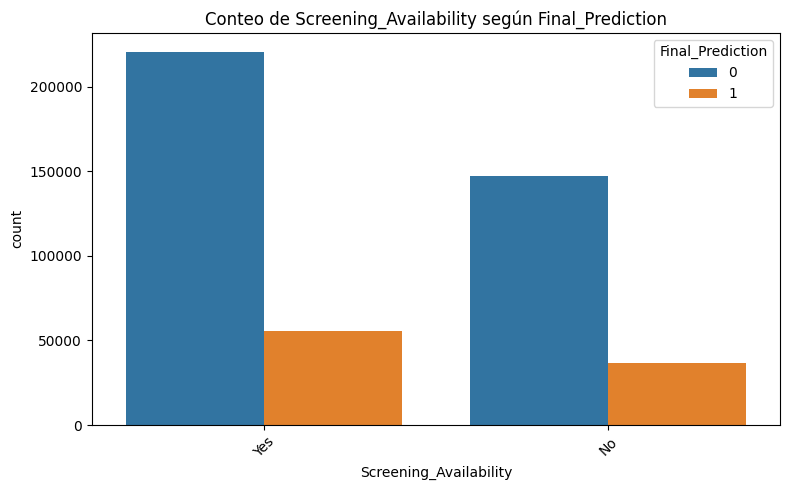

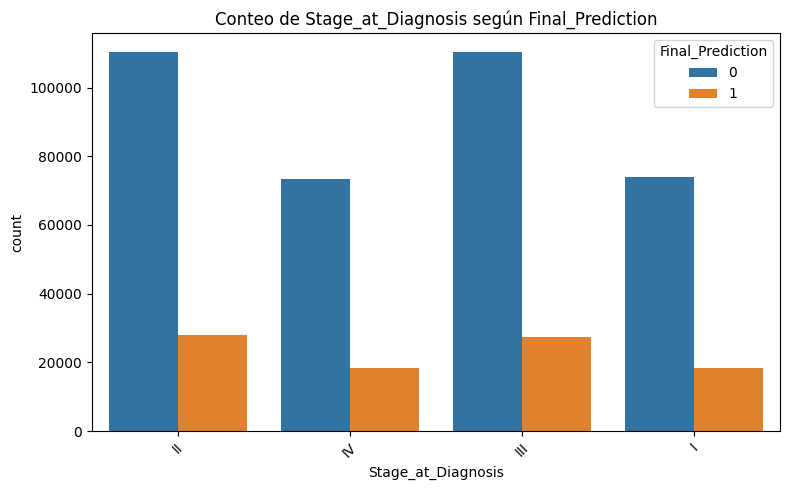

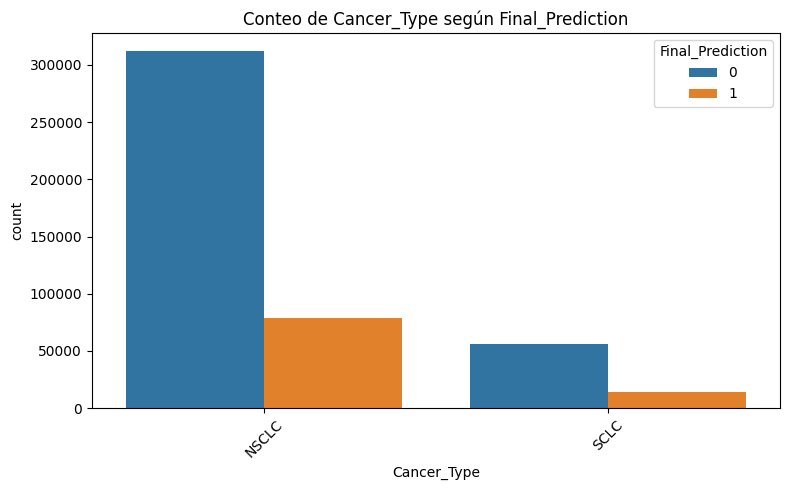

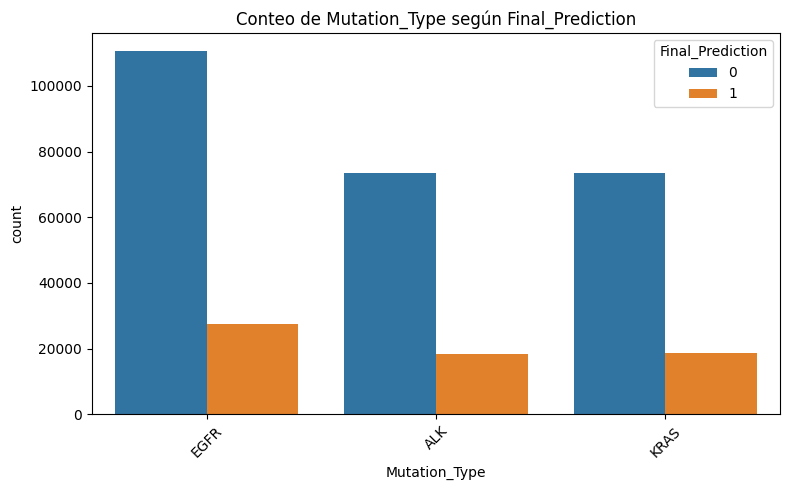

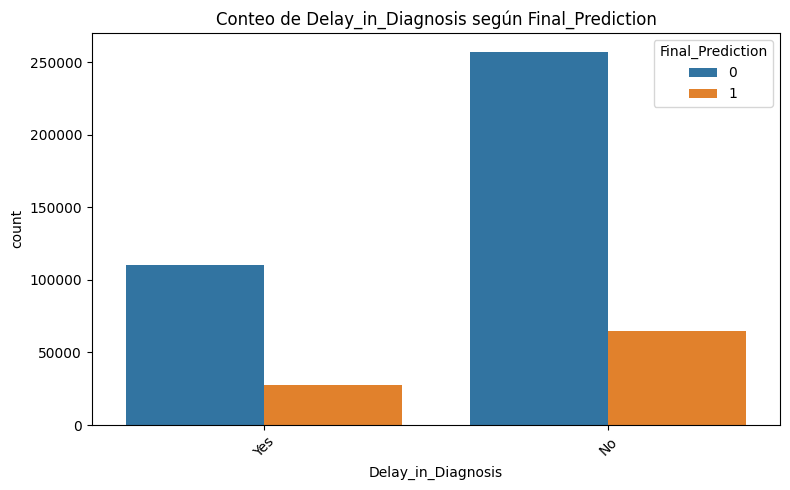

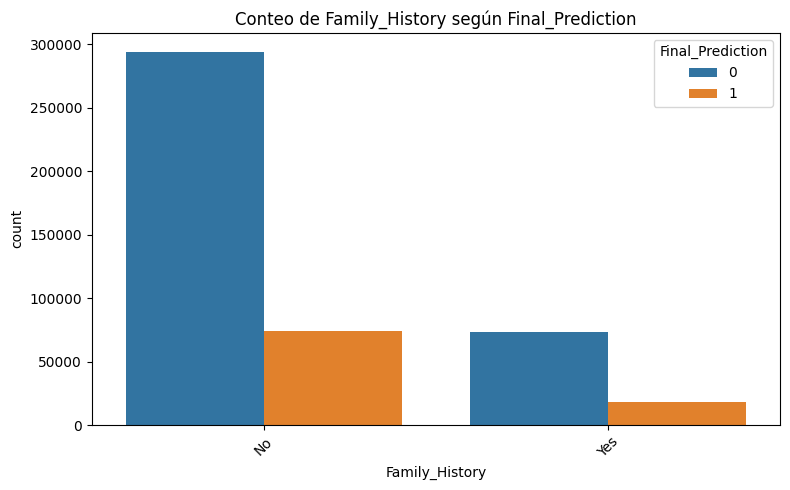

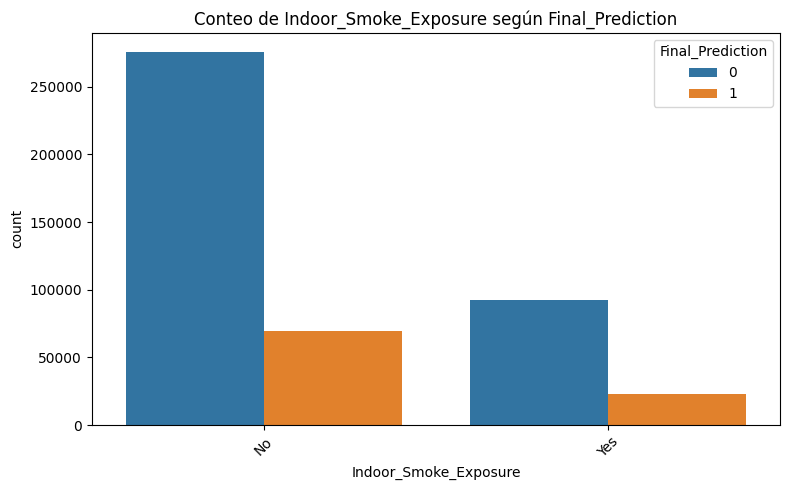

In [5]:

# Variables numéricas: histogramas y boxplots
for col in numerical_features:
    plt.figure(figsize=(12, 5))
    
    # Histograma con KDE
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col, hue='Final_Prediction', multiple='dodge', kde=True)
    plt.title(f'Histograma de {col} según Final_Prediction')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x='Final_Prediction', y=col, data=df)
    plt.title(f'Boxplot de {col} según Final_Prediction')
    
    plt.tight_layout()
    plt.show()

# Variables categóricas: gráficos de barras
for col in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='Final_Prediction', data=df)
    plt.title(f'Conteo de {col} según Final_Prediction')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =============================
# 4. División del Dataset
# =============================

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)


Tamaño del conjunto de entrenamiento: (368233, 18)
Tamaño del conjunto de prueba: (92059, 18)


# =============================
# 5. Preprocesador
# =============================

In [7]:

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# =============================
# 6. Modelo 1: SGDClassifier
# =============================

In [8]:
pipeline_sgd = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42, class_weight='balanced'))
])

# Entrenar modelo base
pipeline_sgd.fit(X_train, y_train)
y_pred_sgd = pipeline_sgd.predict(X_test)

print("----- Modelo 1: SGDClassifier (Base) -----")
print("Accuracy:", accuracy_score(y_test, y_pred_sgd))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_sgd))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_sgd, zero_division=0))
print("Recall (Clase 1):", recall_score(y_test, y_pred_sgd))

# GridSearch para SGD
param_grid_sgd = {
    'classifier__alpha': [1e-4, 1e-3, 1e-2, 1e-1, 1]
}
grid_search_sgd = GridSearchCV(
    pipeline_sgd, 
    param_grid_sgd, 
    cv=5, 
    scoring=cost_scorer, 
    n_jobs=-1
)
grid_search_sgd.fit(X_train, y_train)

print("\nMejores parámetros para SGDClassifier:", grid_search_sgd.best_params_)
print("Mejor score de validación (Cost):", grid_search_sgd.best_score_)

y_pred_sgd_tuned = grid_search_sgd.predict(X_test)
print("----- Modelo 1: SGDClassifier (Optimizado) -----")
print("Recall (Clase 1):", recall_score(y_test, y_pred_sgd_tuned))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_sgd_tuned, zero_division=0))



----- Modelo 1: SGDClassifier (Base) -----
Accuracy: 0.4276822472544781
Matriz de Confusión:
 [[27994 45628]
 [ 7059 11378]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.80      0.38      0.52     73622
           1       0.20      0.62      0.30     18437

    accuracy                           0.43     92059
   macro avg       0.50      0.50      0.41     92059
weighted avg       0.68      0.43      0.47     92059

Recall (Clase 1): 0.6171286000976298

Mejores parámetros para SGDClassifier: {'classifier__alpha': 1}
Mejor score de validación (Cost): -58941.4
----- Modelo 1: SGDClassifier (Optimizado) -----
Recall (Clase 1): 0.0
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     73622
           1       0.00      0.00      0.00     18437

    accuracy                           0.80     92059
   macro avg       0.40      0.50      0.44     92059
weight

# =============================
# 7. Modelo 2: KNeighborsClassifier (RandomizedSearchCV)
# =============================

In [9]:

pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

# Entrenar modelo base
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)

print("\n----- Modelo 2: KNeighborsClassifier (Base) -----")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_knn))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_knn, zero_division=0))
print("Recall (Clase 1):", recall_score(y_test, y_pred_knn))

# Definir distribuciones para búsqueda aleatoria
param_dist_knn = {
    'classifier__n_neighbors': randint(3, 6),        # n_neighbors entre 3 y 5
    'classifier__weights': ['uniform', 'distance']
}

# RandomizedSearchCV en lugar de GridSearchCV
random_search_knn = RandomizedSearchCV(
    pipeline_knn,
    param_dist_knn,
    n_iter=6,          # número de configuraciones aleatorias
    cv=3,              # menos folds para acelerar
    scoring=cost_scorer,
    n_jobs=-1,
    random_state=42
)

random_search_knn.fit(X_train, y_train)

print("\nMejores parámetros para KNeighborsClassifier:", random_search_knn.best_params_)
print("Mejor score de validación (Cost):", random_search_knn.best_score_)

y_pred_knn_tuned = random_search_knn.predict(X_test)
print("----- Modelo 2: KNeighborsClassifier (Optimizado) -----")
print("Recall (Clase 1):", recall_score(y_test, y_pred_knn_tuned))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_knn_tuned, zero_division=0))



----- Modelo 2: KNeighborsClassifier (Base) -----
Accuracy: 0.7645205791937779
Matriz de Confusión:
 [[69318  4304]
 [17374  1063]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.80      0.94      0.86     73622
           1       0.20      0.06      0.09     18437

    accuracy                           0.76     92059
   macro avg       0.50      0.50      0.48     92059
weighted avg       0.68      0.76      0.71     92059

Recall (Clase 1): 0.05765580083527689

Mejores parámetros para KNeighborsClassifier: {'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}
Mejor score de validación (Cost): -230004.66666666666
----- Modelo 2: KNeighborsClassifier (Optimizado) -----
Recall (Clase 1): 0.1065249227097684
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.80      0.90      0.84     73622
           1       0.20      0.11      0.14     18437

    accuracy             

# =============================
# 8. Visualizaciones
# =============================

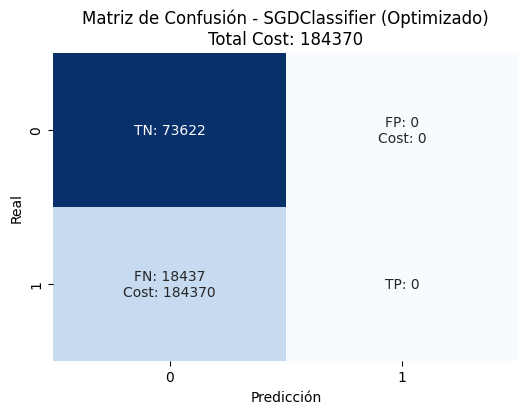

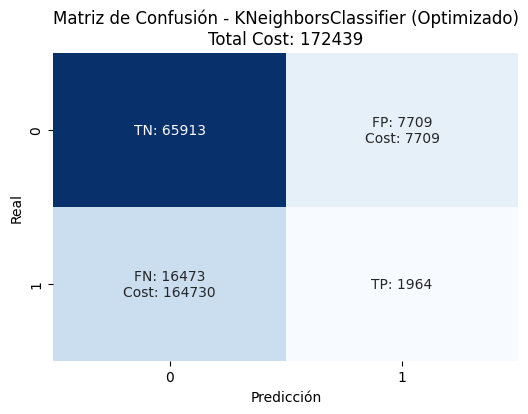

In [10]:

def plot_confusion_matrix_with_details(cm, title, cost_fn=10, cost_fp=1):
    """
    Dibuja la matriz de confusión con anotaciones detalladas.
    Parámetros:
      - cm: Matriz de confusión (2x2) -> [[TN, FP], [FN, TP]].
      - title: Título para el gráfico.
      - cost_fn: Costo asignado a falsos negativos.
      - cost_fp: Costo asignado a falsos positivos.
    """
    TN, FP, FN, TP = cm.ravel()
    total_cost = cost_fn * FN + cost_fp * FP
    annot = np.array([
        [f"TN: {TN}", f"FP: {FP}\nCost: {cost_fp*FP}"],
        [f"FN: {FN}\nCost: {cost_fn*FN}", f"TP: {TP}"]
    ])
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False)
    plt.title(f"{title}\nTotal Cost: {total_cost}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

# Matrices de confusión (modelo base vs optimizado)
cm_sgd = confusion_matrix(y_test, y_pred_sgd_tuned)
cm_knn = confusion_matrix(y_test, y_pred_knn_tuned)

plot_confusion_matrix_with_details(cm_sgd, "Matriz de Confusión - SGDClassifier (Optimizado)")
plot_confusion_matrix_with_details(cm_knn, "Matriz de Confusión - KNeighborsClassifier (Optimizado)")


# =============================
# 8.2 Gráfico de Barras de Métricas
# =============================

c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

                 Modelo  Recall Clase 1  Precisión Clase 1  F1-Score Clase 1
0         SGDClassifier        0.000000           0.000000          0.000000
1  KNeighborsClassifier        0.106525           0.203039          0.139737


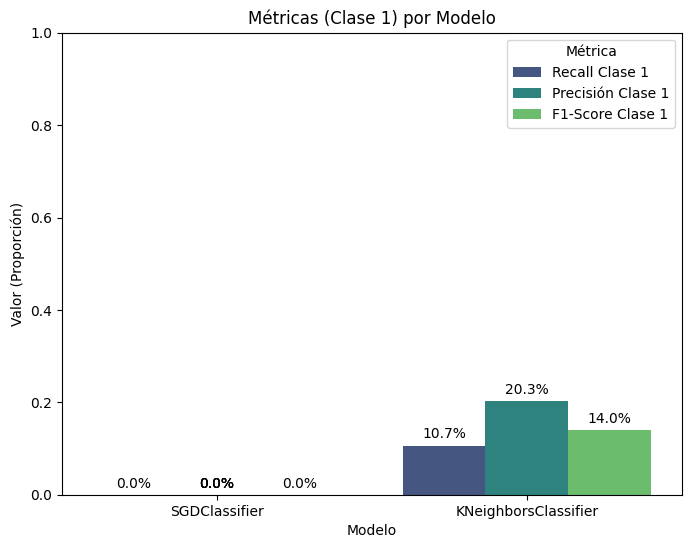

In [11]:

metrics = {
    'Modelo': ['SGDClassifier', 'KNeighborsClassifier'],
    'Recall Clase 1': [recall_score(y_test, y_pred_sgd_tuned), recall_score(y_test, y_pred_knn_tuned)],
    'Precisión Clase 1': [
        classification_report(y_test, y_pred_sgd_tuned, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_knn_tuned, output_dict=True)['1']['precision']
    ],
    'F1-Score Clase 1': [
        classification_report(y_test, y_pred_sgd_tuned, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_knn_tuned, output_dict=True)['1']['f1-score']
    ]
}
df_metrics = pd.DataFrame(metrics)
print(df_metrics)

df_melted = pd.melt(
    df_metrics,
    id_vars=['Modelo'], 
    value_vars=['Recall Clase 1', 'Precisión Clase 1', 'F1-Score Clase 1'],
    var_name='Métrica',
    value_name='Valor'
)

plt.figure(figsize=(8, 6))
barplot = sns.barplot(
    x='Modelo', y='Valor', hue='Métrica', data=df_melted, palette='viridis'
)
plt.ylim(0, 1)
plt.title("Métricas (Clase 1) por Modelo")
plt.ylabel("Valor (Proporción)")
plt.xlabel("Modelo")

for p in barplot.patches:
    height = p.get_height()
    label_text = f"{height*100:.1f}%"
    barplot.annotate(
        label_text,
        (p.get_x() + p.get_width()/2., height),
        ha='center', va='bottom', fontsize=10, color='black',
        xytext=(0, 3), textcoords='offset points'
    )
plt.legend(title='Métrica')
plt.show()

# =============================
# 8.3 Curvas ROC, Precisión-Recall, Calibración, etc.
# =============================

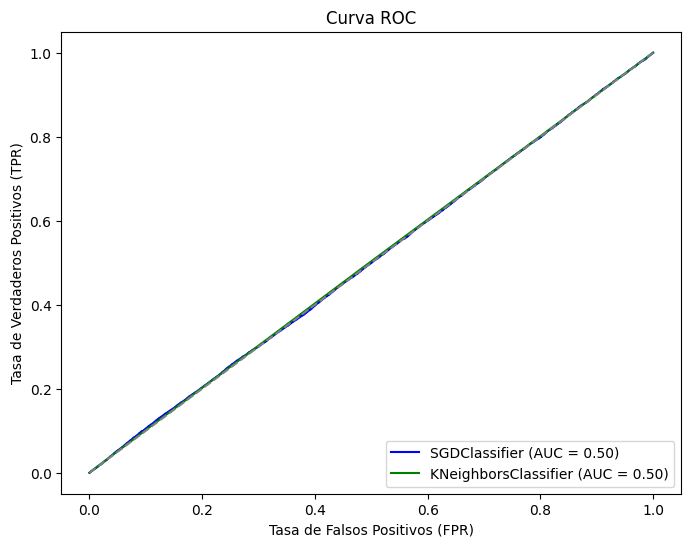

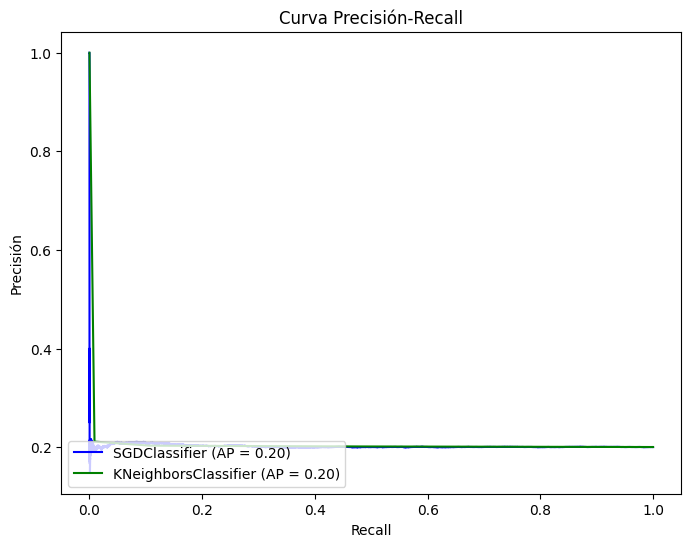

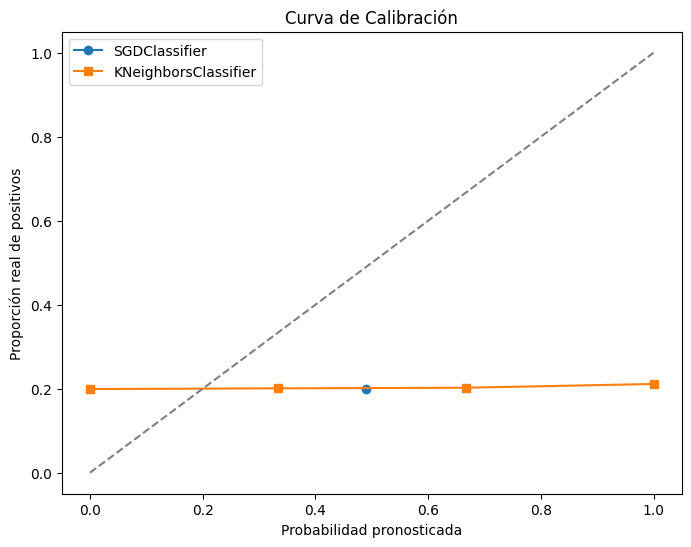

In [12]:

try:
    y_score_sgd = grid_search_sgd.decision_function(X_test)
except:
    y_score_sgd = grid_search_sgd.predict_proba(X_test)[:,1]

y_score_knn = random_search_knn.predict_proba(X_test)[:,1]

# Curva ROC
fpr_sgd, tpr_sgd, _ = roc_curve(y_test, y_score_sgd)
roc_auc_sgd = auc(fpr_sgd, tpr_sgd)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8,6))
plt.plot(fpr_sgd, tpr_sgd, color='blue', label=f"SGDClassifier (AUC = {roc_auc_sgd:.2f})")
plt.plot(fpr_knn, tpr_knn, color='green', label=f"KNeighborsClassifier (AUC = {roc_auc_knn:.2f})")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

# Curva Precisión-Recall
precision_sgd, recall_sgd, _ = precision_recall_curve(y_test, y_score_sgd)
ap_sgd = average_precision_score(y_test, y_score_sgd)

precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_score_knn)
ap_knn = average_precision_score(y_test, y_score_knn)

plt.figure(figsize=(8,6))
plt.plot(recall_sgd, precision_sgd, color='blue', label=f"SGDClassifier (AP = {ap_sgd:.2f})")
plt.plot(recall_knn, precision_knn, color='green', label=f"KNeighborsClassifier (AP = {ap_knn:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precisión")
plt.title("Curva Precisión-Recall")
plt.legend(loc="lower left")
plt.show()

# Curva de Calibración
y_prob_sgd = grid_search_sgd.predict_proba(X_test)[:,1]
prob_true_sgd, prob_pred_sgd = calibration_curve(y_test, y_prob_sgd, n_bins=10)

y_prob_knn = random_search_knn.predict_proba(X_test)[:,1]
prob_true_knn, prob_pred_knn = calibration_curve(y_test, y_prob_knn, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred_sgd, prob_true_sgd, marker='o', label='SGDClassifier')
plt.plot(prob_pred_knn, prob_true_knn, marker='s', label='KNeighborsClassifier')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("Probabilidad pronosticada")
plt.ylabel("Proporción real de positivos")
plt.title("Curva de Calibración")
plt.legend(loc="upper left")
plt.show()
